In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

In [2]:
axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '12' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [4]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

z_samp = Prop.z_samp

In [5]:
# sets the conditions for the study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop_TG = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
              elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
              rho_ice=0.92) # (g/cm^3) density used in Taylor Glacier analysis
h_bins_TG = np.arange(0, 1001, 1)
Prop_TG.set_mass_depth(z_bins=h_bins_TG/Prop_TG.rho_ice, h_bins=h_bins_TG, z_min=0., z_deep=h_bins_TG[-1]/Prop_TG.rho_ice)
# sample mid depths = [6.85, 10., 15, 19.5, 40.5, 51, 61.5, 72.]
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast_TG = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg_TG = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C_TG = np.swapaxes([df_Pfast_TG.T, df_Pneg_TG.T], 0, 1)
model_names_TG = list(df_Pfast_TG.columns)

# The only production model being used is Heisinger
i = model_names_TG.index('Heisinger')
prod_cut_TG = np.arange(len(P_14C_TG))[i:i+1]

flow = 'sample'
flowpath = loadmat('matlab/MC_14CO_mod/flowpath_{}.mat'.format(flow))
age = flowpath['age'][0]

Prop_TG.Phi['prod']=P_14C_TG[prod_cut_TG]
C_response_TG, C_init_TG = F.Taylor_flow_response(Prop_TG, flow)

TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')
CO_exp_TG_data = TG_data['CO_molec'][3:,0]
CO_err_TG_data = TG_data['CO_molec_err'][3:,0]/2.
z_samp_TG = TG_data['sample_depth_CO'][3:,0]

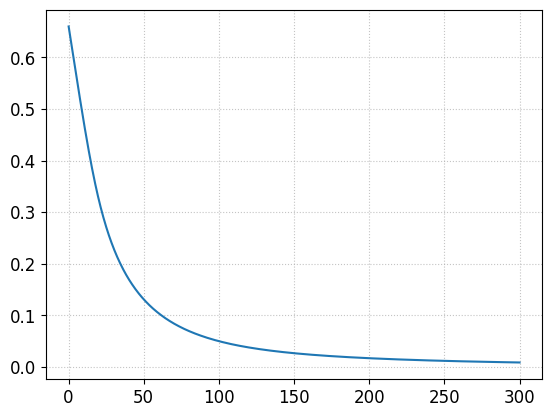

In [6]:
plt.plot(Prop.z, P_14C[0,0])

In [7]:
P_14C[0,1][-1]/P_14C[0,1][Prop.z>100][0]

np.float64(0.02009461317976725)

In [85]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
Period = t_bins[-1]-t_bins[0]
t_scale = t/Period # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/Period).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

dt_TG = 0.5
t_bins_TG = np.arange(age[0], age[-1]+dt_TG, dt_TG) # time integration steps
t_bins_TG -= t_bins_TG[-1]
t_TG = (t_bins_TG[:-1]+t_bins_TG[1:])/2
t_scale_TG = t_TG/Period
t_bins_scale_TG = (t_bins_TG/Period).reshape((1,-1))
dt_scale_TG = np.diff(t_bins_scale_TG, axis=-1)

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

f_step_TG = ((t_step[1:]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale_TG[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

In [9]:
Blur = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/20))**2/2)
Blur /= np.sum(Blur, axis=0, keepdims=True)

Blur_TG = np.exp(-((t_TG.reshape((-1,1))-t_TG.reshape((1,-1)))/(Period/20))**2/2)
Blur_TG /= np.sum(Blur_TG, axis=0, keepdims=True)

In [10]:
C_step = np.swapaxes(f_step @ C_response, -3,-2)
C_step_TG = np.swapaxes(f_step_TG @ C_response_TG, -3,-2)
C_step_all = np.concatenate((C_step, C_step_TG[0]), axis=-1)

In [11]:
f_interp_to_TG = ((t_bins[1:].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG) - (t_bins[:-1].reshape((-1,1))-t_bins_TG[:-1].reshape((1,-1))).clip(0,dt_TG))/dt_TG

In [12]:
f_true = np.array([0.08,0.06])
#f_true = np.array([0.,1.])
CO_response = f_true @ np.swapaxes(C_response, -3,-2)
CO_response_TG = f_interp_to_TG @ (f_true @ np.swapaxes(C_response_TG, -3,-2))
CO_init_TG = f_true @ C_init_TG

In [13]:
N_f = 21
tf_min, tf_max = np.pi/6, np.pi/3
theta_f = np.linspace(tf_min, tf_max, N_f)
f_unit = np.array([np.cos(theta_f), np.sin(theta_f)]).T
print(theta_f*180/np.pi)

[30.  31.5 33.  34.5 36.  37.5 39.  40.5 42.  43.5 45.  46.5 48.  49.5
 51.  52.5 54.  55.5 57.  58.5 60. ]


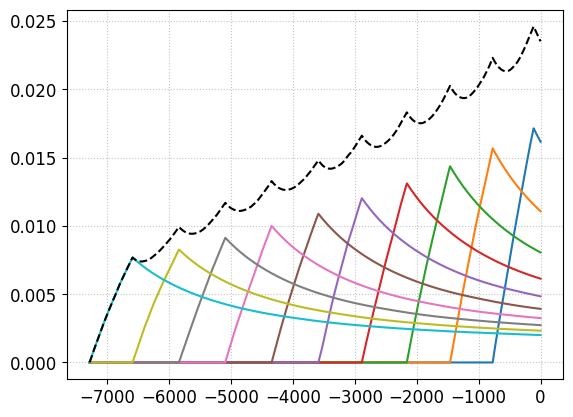

In [14]:
plt.plot(t, CO_response[0])
plt.plot(t, np.sqrt(np.sum(CO_response[0]**2, axis=-1)), c='k', ls='--')
plt.show()

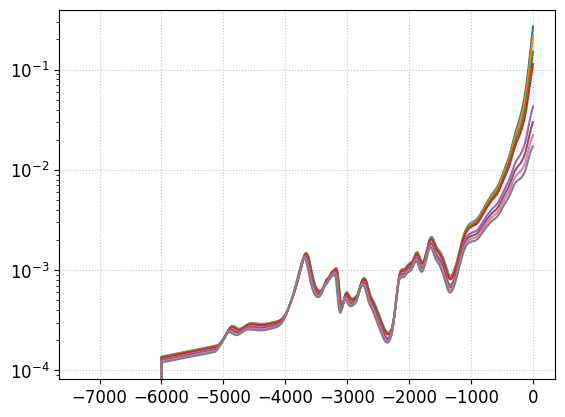

In [15]:
plt.plot(t, CO_response_TG[0,0])
plt.yscale('log')
plt.show()

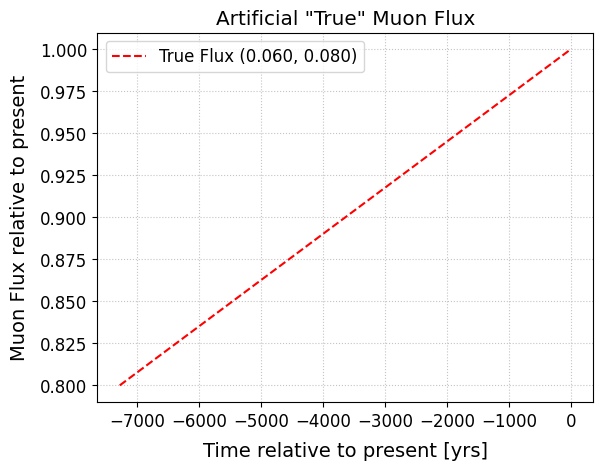

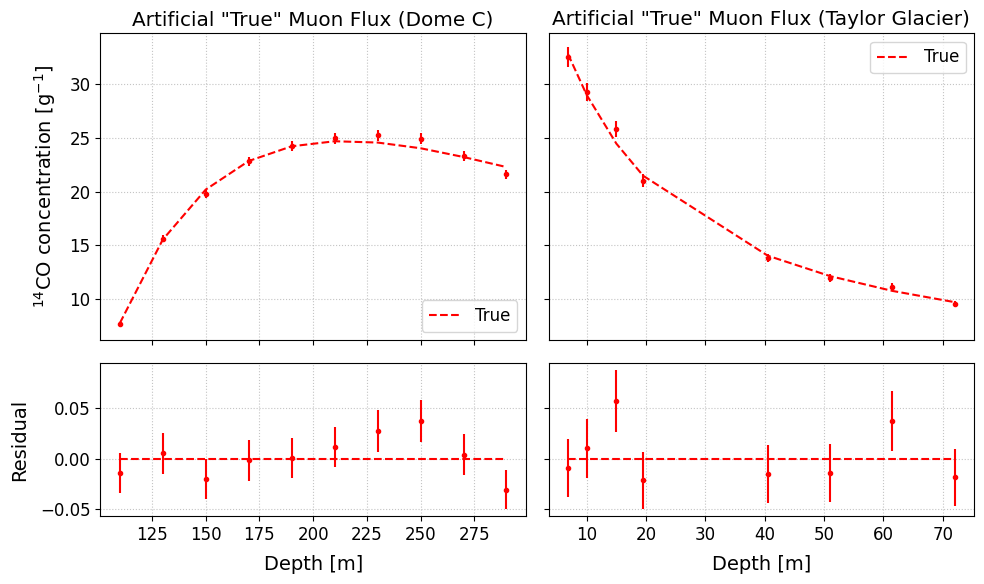

In [16]:
#N = 1
amp = 0.2

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

#f_samp = np.append(np.random.normal(1.,amp*np.sqrt(N_interp)/2,(len(CO_samp)-1)), 1.)
flux_noise = np.random.normal(0., 1., (len(t)))

Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/10))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

#flux_smooth = gaussian_filter(flux_noise, sigma=len(t)/10, mode='constant')
flux_smooth = flux_noise @ Smooth
#flux_true = 1 + amp*flux_smooth/np.std(gaussian_filter(flux_smooth, sigma=len(t)/20, mode='constant'))
flux_true = 1 + amp*flux_smooth/np.std(flux_smooth @ Blur)
flux_true -= flux_true[-1]-1

flux_true = amp*t_scale + 1

CO_true = flux_true @ CO_response[0]
CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
# A note on the initial concentration of CO at Taylor Glacier
# The equilibrium value will be sensitive to changes in the muon flux before integration starts.
# I haven't yet thought through how to account for that, so for the moment this is ignored
CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

#Sigma = np.diag(CO_err**2)
true_err = CO_true*rel_err
true_cov = np.diag(true_err**2) * (1-rel_cov) + true_err.reshape((-1,1))*true_err.reshape((1,-1)) * rel_cov
true_cov_inv = np.linalg.inv(true_cov)

true_err_TG = CO_true_TG*rel_err_TG
true_cov_TG = np.diag(true_err_TG**2) * (1-rel_cov_TG) + true_err_TG.reshape((-1,1))*true_err_TG.reshape((1,-1)) * rel_cov_TG
true_cov_inv_TG = np.linalg.inv(true_cov_TG)

#s = np.random.normal(0,rel_err,(len(Prop.z_samp)))
CO_exp = np.random.multivariate_normal(mean=CO_true, cov=true_cov)
CO_exp_TG = np.random.multivariate_normal(mean=CO_true_TG, cov=true_cov_TG)
CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

#CO_exp = CO_true
#CO_exp_TG = CO_true_TG
#CO_exp_all = CO_true_all

CO_err = np.abs(CO_exp * rel_err)
CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

#CO_exp_TG = CO_exp_TG_data
#CO_err_TG = CO_err_TG_data

rel_err_all = np.concatenate(([rel_err]*len(CO_exp), [rel_err_TG]*len(CO_exp_TG)))

Sigma = np.diag(CO_err**2) * (1-rel_cov) + CO_err.reshape((-1,1))*CO_err.reshape((1,-1)) * rel_cov
Sigma_inv = np.linalg.inv(Sigma)

Sigma_TG = np.diag(CO_err_TG**2) * (1-rel_cov_TG) + CO_err_TG.reshape((-1,1))*CO_err_TG.reshape((1,-1)) * rel_cov_TG
Sigma_inv_TG = np.linalg.inv(Sigma_TG)

Sigma_all = np.zeros((len(CO_exp_all),len(CO_exp_all)))
Sigma_all[:len(CO_exp),:len(CO_exp)] = Sigma
Sigma_all[len(CO_exp):,len(CO_exp):] = Sigma_TG
Sigma_inv_all = np.linalg.inv(Sigma_all)

plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Artificial "True" Muon Flux')
plt.show()

fig, ((ax1,ax3),(ax2,ax4)) = plt.subplots(2,2, figsize=(10,6), tight_layout=True, sharex='col', sharey='row', height_ratios=[2,1])

ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='True')
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=np.abs(CO_err/ CO_true), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Artificial "True" Muon Flux (Dome C)')
ax1.legend(loc='lower right')

ax3.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='True')
ax3.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')

ax4.plot(z_samp_TG, CO_true_TG / CO_true_TG -1, ls='--', c='r')
ax4.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=np.abs(CO_err_TG/ CO_true_TG), fmt='.', c='r')

ax3.set(#xlabel='Depth [m]',
           #xscale='log',
           #ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax4.set(xlabel='Depth [m]',
           #xscale='log',
           #ylabel='Residual',
           #yscale='log',
      )
ax3.title.set_text('Artificial "True" Muon Flux (Taylor Glacier)')
ax3.legend(loc='upper right')

plt.show()

,Dome C,Taylor Glacier,All Data
True χ2 (reduced),9.6 (0.96),6.8 (0.85),16.3 (0.91)
True p-value (σ),0.480 (0.7σ),0.561 (0.6σ),0.569 (0.6σ)
Null Model χ2 (reduced),14.4 (1.80),6.6 (1.09),48.9 (3.05)
Null Model p-value (σ),0.071 (1.8σ),0.682 (0.4σ),0.000 (4.1σ)


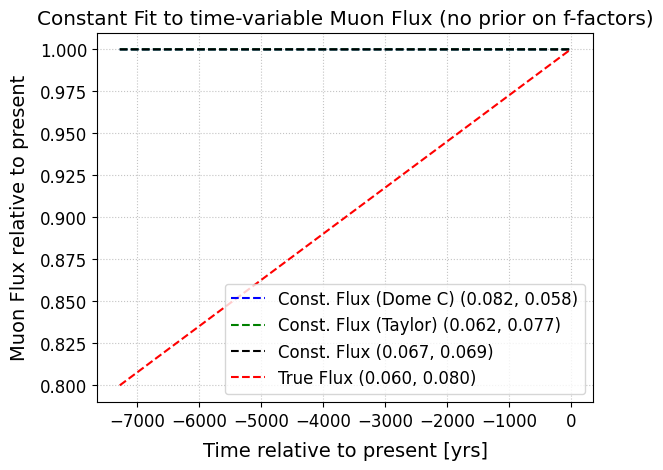

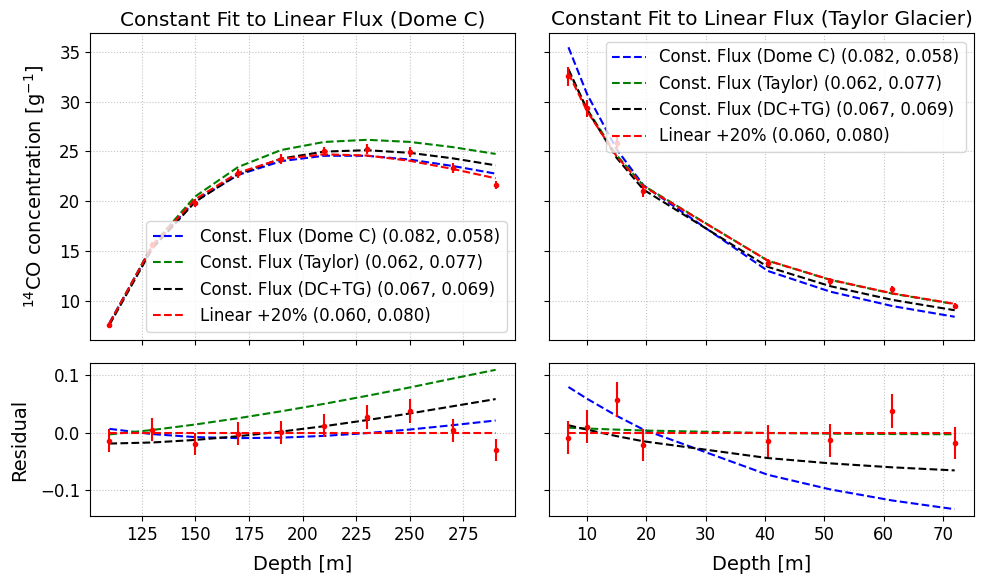

In [17]:
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
C0_all = np.concatenate((C0, C0_TG[0]), axis=-1)

f_hat_null = np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv @ CO_exp
f_hat_null_TG = np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG @ CO_exp_TG
f_hat_null_all = np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all @ CO_exp_all

#chi2_true = (CO_true-CO_exp)@true_cov_inv@(CO_true-CO_exp)
chi2_true = (CO_true-CO_exp)@Sigma_inv@(CO_true-CO_exp)
p_true = stats.chi2.sf(chi2_true, len(CO_exp))
sig_true = stats.norm.isf(p_true/2.)

chi2_true_TG = (CO_true_TG-CO_exp_TG)@Sigma_inv_TG@(CO_true_TG-CO_exp_TG)
p_true_TG = stats.chi2.sf(chi2_true_TG, len(CO_exp_TG))
sig_true_TG = stats.norm.isf(p_true_TG/2.)

chi2_true_all = (CO_true_all-CO_exp_all)@Sigma_inv_all@(CO_true_all-CO_exp_all)
p_true_all = stats.chi2.sf(chi2_true_all, len(CO_exp_all))
sig_true_all = stats.norm.isf(p_true_all/2.)

CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum((CO_null - CO_exp) @ Sigma_inv *(CO_null - CO_exp), axis=-1)[0]
p_null = stats.chi2.sf(chi2_null, len(CO_exp)-len(f_hat_null[0]))
sig_null = stats.norm.isf(p_null/2.)

CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
chi2_null_TG = np.sum((CO_null_TG[0] - CO_exp_TG) @ Sigma_inv_TG *(CO_null_TG[0] - CO_exp_TG), axis=-1)[0]
p_null_TG = stats.chi2.sf(chi2_null_TG, len(CO_exp)-len(f_hat_null_TG[0]))
sig_null_TG = stats.norm.isf(p_null_TG/2.)

CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
chi2_null_all = np.sum((CO_null_all - CO_exp_all) @ Sigma_inv_all *(CO_null_all - CO_exp_all), axis=-1)[0]
p_null_all = stats.chi2.sf(chi2_null_all, len(CO_exp_all)-len(f_true))
sig_null_all = stats.norm.isf(p_null_all/2.)

data = [
    ['{:.1f} ({:.2f})'.format(c2, c2 / dof) for c2, dof in [(chi2_true,len(CO_exp)),(chi2_true_TG, len(CO_exp_TG)),(chi2_true_all, len(CO_exp_all))]],
    ['{:.3f} ({:.1f}σ)'.format(p,s) for p,s in [(p_true, sig_true),(p_true_TG, sig_true_TG),(p_true_all, sig_true_all)]],
    ['{:.1f} ({:.2f})'.format(c2, c2 / dof) for c2, dof in [(chi2_null,len(CO_exp)-len(f_true)),(chi2_null_TG, len(CO_exp_TG)-len(f_true)),(chi2_null_all, len(CO_exp_all)-len(f_true))]],
    ['{:.3f} ({:.1f}σ)'.format(p,s) for p,s in [(p_null, sig_null),(p_null_TG, sig_null_TG),(p_null_all, sig_null_all)]]
]

display(pd.DataFrame(data, ['True χ2 (reduced)', 'True p-value (σ)', 'Null Model χ2 (reduced)', 'Null Model p-value (σ)'], ['Dome C', 'Taylor Glacier', 'All Data']))

plt.plot(t, t*0. + 1., ls='--', c='b', label='Const. Flux (Dome C) ({1:.3f}, {0:.3f})'.format(*f_hat_null[0]))
plt.plot(t, t*0. + 1., ls='--', c='g', label='Const. Flux (Taylor) ({1:.3f}, {0:.3f})'.format(*f_hat_null_TG[0,0]))
plt.plot(t, t*0. + 1., ls='--', c='k', label='Const. Flux ({1:.3f}, {0:.3f})'.format(*f_hat_null_all[0]))
plt.plot(t, flux_true, ls='--', c='r', label='True Flux ({1:.3f}, {0:.3f})'.format(*f_true))
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Muon Flux relative to present')
plt.legend()
plt.title('Constant Fit to time-variable Muon Flux (no prior on f-factors)')
plt.show()


fig, ((ax1,ax3),(ax2,ax4)) = plt.subplots(2,2, figsize=(10,6), tight_layout=True, sharex='col', sharey='row', height_ratios=[2,1])

ax1.plot(Prop.z_samp, f_hat_null[0] @ C0[0], ls='--', c='b', label='Const. Flux (Dome C) ({1:.3f}, {0:.3f})'.format(*f_hat_null[0]))
ax1.plot(Prop.z_samp, f_hat_null_TG[0,0] @ C0[0], ls='--', c='g', label='Const. Flux (Taylor) ({1:.3f}, {0:.3f})'.format(*f_hat_null_TG[0,0]))
ax1.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0], ls='--', c='k', label='Const. Flux (DC+TG) ({1:.3f}, {0:.3f})'.format(*f_hat_null_all[0]))
ax1.plot(Prop.z_samp, CO_true, ls='--', c='r', label='Linear +20% ({1:.3f}, {0:.3f})'.format(*f_true))
ax1.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')

ax2.plot(Prop.z_samp, f_hat_null[0] @ C0[0] / CO_true -1, ls='--', c='b')
ax2.plot(Prop.z_samp, f_hat_null_TG[0,0] @ C0[0] / CO_true -1, ls='--', c='g')
ax2.plot(Prop.z_samp, f_hat_null_all[0] @ C0[0] / CO_true -1, ls='--', c='k')
ax2.plot(Prop.z_samp, CO_true / CO_true -1, ls='--', c='r')
ax2.errorbar(Prop.z_samp, CO_exp / CO_true -1, yerr=np.abs(CO_err/ CO_true), fmt='.', c='r')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Constant Fit to Linear Flux (Dome C)')
ax1.legend(loc='lower right')

ax3.plot(z_samp_TG, f_hat_null[0] @ C0_TG[0,0], ls='--', c='b', label='Const. Flux (Dome C) ({1:.3f}, {0:.3f})'.format(*f_hat_null[0]))
ax3.plot(z_samp_TG, f_hat_null_TG[0,0] @ C0_TG[0,0], ls='--', c='g', label='Const. Flux (Taylor) ({1:.3f}, {0:.3f})'.format(*f_hat_null_TG[0,0]))
ax3.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0], ls='--', c='k', label='Const. Flux (DC+TG) ({1:.3f}, {0:.3f})'.format(*f_hat_null_all[0]))
ax3.plot(z_samp_TG, CO_true_TG, ls='--', c='r', label='Linear +20% ({1:.3f}, {0:.3f})'.format(*f_true))
ax3.errorbar(z_samp_TG, CO_exp_TG, yerr=CO_err_TG, fmt='.', c='r')

ax4.plot(z_samp_TG, f_hat_null[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='b')
ax4.plot(z_samp_TG, f_hat_null_TG[0,0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='g')
ax4.plot(z_samp_TG, f_hat_null_all[0] @ C0_TG[0,0] / CO_true_TG -1, ls='--', c='k')
ax4.plot(z_samp_TG, CO_true_TG / CO_true_TG -1, ls='--', c='r')
ax4.errorbar(z_samp_TG, CO_exp_TG / CO_true_TG -1, yerr=np.abs(CO_err_TG/ CO_true_TG), fmt='.', c='r')

ax3.set(#xlabel='Depth [m]',
           #xscale='log',
           #ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax4.set(xlabel='Depth [m]',
           #xscale='log',
           #ylabel='Residual',
           #yscale='log',
      )
ax3.title.set_text('Constant Fit to Linear Flux (Taylor Glacier)')
ax3.legend(loc='upper right')

plt.show()

In [86]:
flux_scale = t_scale#/np.mean(t_scale)
#flux_scale /= np.std(flux_scale @ Blur, axis=-1)

In [88]:
N = 1000

da = 0.01
amps = np.arange(0.,1.+da,da)
#amp = 0.05

flux_true = amps.reshape((1,-1,1))*flux_scale
flux_true += 1-flux_true[:,:,-1:]

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

#flux_true = amp*t_scale + 1

CO_true = flux_true @ CO_response[0]
CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
# A note on the initial concentration of CO at Taylor Glacier
# The equilibrium value will be sensitive to changes in the muon flux before integration starts.
# I haven't yet thought through how to account for that, so for the moment this is ignored
CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

#Sigma = np.diag(CO_err**2)
#true_err = CO_true*rel_err
#true_cov = true_err.reshape((-1,1))*true_err.reshape((1,-1)) * rel_cov
#true_cov[:,np.arange(len(z_samp)),np.arange(len(z_samp))] = true_err**2
#true_cov_inv = np.linalg.inv(true_cov)

#true_err_TG = CO_true_TG*rel_err_TG
#true_cov_TG = true_err_TG.reshape((-1,1))*true_err_TG.reshape((1,-1)) * rel_cov_TG
#true_cov_TG[:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = true_err_TG**2
#true_cov_inv_TG = np.linalg.inv(true_cov_TG)

s = np.random.normal(1, rel_err, (N,1,len(z_samp)))
s_TG = np.random.normal(1, rel_err_TG, (N,1,len(z_samp_TG)))

#CO_exp = np.random.multivariate_normal(mean=CO_true, cov=true_cov)
#CO_exp_TG = np.random.multivariate_normal(mean=CO_true_TG, cov=true_cov_TG)
CO_exp = CO_true*s
CO_exp_TG = CO_true_TG*s_TG
CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

#CO_exp = CO_true
#CO_exp_TG = CO_true_TG
#CO_exp_all = CO_true_all

CO_err = np.abs(CO_exp * rel_err)
CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

#CO_exp_TG = CO_exp_TG_data
#CO_err_TG = CO_err_TG_data

#rel_err_all = np.concatenate(([rel_err]*len(z_samp), [rel_err_TG]*len(z_samp_TG)))

Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,len(z_samp))) * rel_cov
Sigma[:,:,np.arange(len(z_samp)),np.arange(len(z_samp))] = CO_err**2
Sigma_inv = np.linalg.inv(Sigma)

Sigma_TG = CO_err_TG.reshape((*CO_err_TG.shape,1))*CO_err_TG.reshape((*CO_err_TG.shape[:-1],1,len(z_samp_TG))) * rel_cov_TG
Sigma_TG[:,:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = CO_err_TG**2
Sigma_inv_TG = np.linalg.inv(Sigma_TG)

Sigma_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_all[:,:,:len(z_samp),:len(z_samp)] = Sigma
Sigma_all[:,:,len(z_samp):,len(z_samp):] = Sigma_TG
Sigma_inv_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_inv_all[:,:,:len(z_samp),:len(z_samp)] = Sigma_inv
Sigma_inv_all[:,:,len(z_samp):,len(z_samp):] = Sigma_inv_TG

In [89]:
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

f_hat_null = np.sum(np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv * CO_exp.reshape((*CO_exp.shape[:-1],1,len(z_samp))), axis=-1)
f_hat_null_TG = np.sum(np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG * CO_exp_TG.reshape((*CO_exp_TG.shape[:-1],1,len(z_samp_TG))), axis=-1)
f_hat_null_all = np.sum(np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all * CO_exp_all.reshape((*CO_exp_all.shape[:-1],1,len(z_samp)+len(z_samp_TG))), axis=-1)

Text(0.5, 1.0, 'Reconstructed Constant f-factors, Slope = 0%')

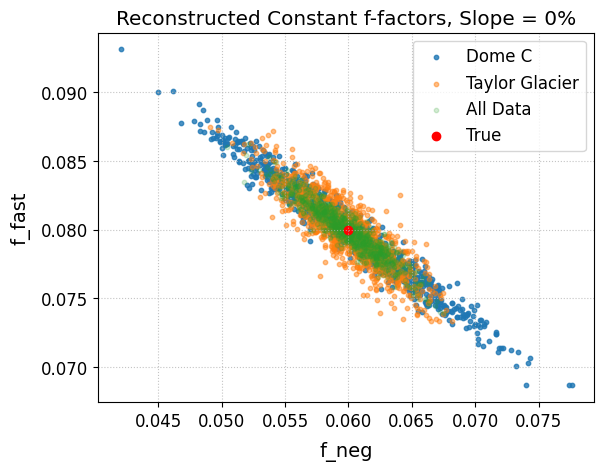

In [90]:
i=0
plt.scatter(f_hat_null[:,i,1], f_hat_null[:,i,0], s=10, alpha=0.8, label='Dome C')
plt.scatter(f_hat_null_TG[:,i,1],f_hat_null_TG[:,i,0], s=10, alpha=0.5, label='Taylor Glacier')
plt.scatter(f_hat_null_all[:,i,1],f_hat_null_all[:,i,0], s=10, alpha=0.2, label='All Data')
plt.scatter(f_true[1], f_true[0], c='r', label='True')
plt.xlabel('f_neg')
plt.ylabel('f_fast')
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
plt.legend()
plt.title('Reconstructed Constant f-factors, Slope = {:.0f}%'.format(amps[i]*100))

Text(0.5, 1.0, 'Best-Fit Constant f-factors, Linear Slope = $\\pm$100%')

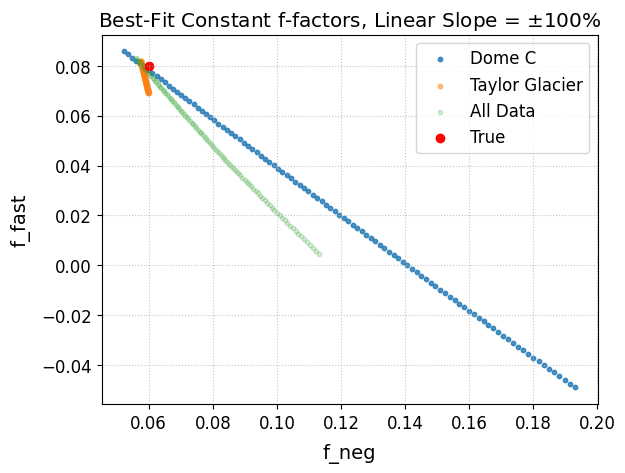

In [91]:
i=0
plt.scatter(f_hat_null[i,:,1], f_hat_null[i,:,0], s=10, alpha=0.8, label='Dome C')
plt.scatter(f_hat_null_TG[i,:,1],f_hat_null_TG[i,:,0], s=10, alpha=0.5, label='Taylor Glacier')
plt.scatter(f_hat_null_all[i,:,1],f_hat_null_all[i,:,0], s=10, alpha=0.2, label='All Data')
plt.scatter(f_true[1], f_true[0], c='r', label='True')
plt.xlabel('f_neg')
plt.ylabel('f_fast')
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
plt.legend()
plt.title(r'Best-Fit Constant f-factors, Linear Slope = $\pm${:.0f}%'.format(amps[-1]*100))

In [92]:
CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum(np.sum((CO_null - CO_exp).reshape((*CO_null.shape,1)) * Sigma_inv, axis=-2) *(CO_null - CO_exp), axis=-1)
p_null = stats.chi2.sf(chi2_null, len(z_samp)-len(f_true))
sig_null = stats.norm.isf(p_null/2.)

CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
chi2_null_TG = np.sum(np.sum((CO_null_TG - CO_exp_TG).reshape((*CO_null_TG.shape,1)) * Sigma_inv_TG, axis=-2) *(CO_null_TG - CO_exp_TG), axis=-1)
p_null_TG = stats.chi2.sf(chi2_null_TG, len(z_samp_TG)-len(f_true))
sig_null_TG = stats.norm.isf(p_null_TG/2.)

CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
chi2_null_all = np.sum(np.sum((CO_null_all - CO_exp_all).reshape((*CO_null_all.shape,1)) * Sigma_inv_all, axis=-2) *(CO_null_all - CO_exp_all), axis=-1)
p_null_all = stats.chi2.sf(chi2_null_all, len(z_samp)+len(z_samp_TG)-len(f_true))
sig_null_all = stats.norm.isf(p_null_all/2.)

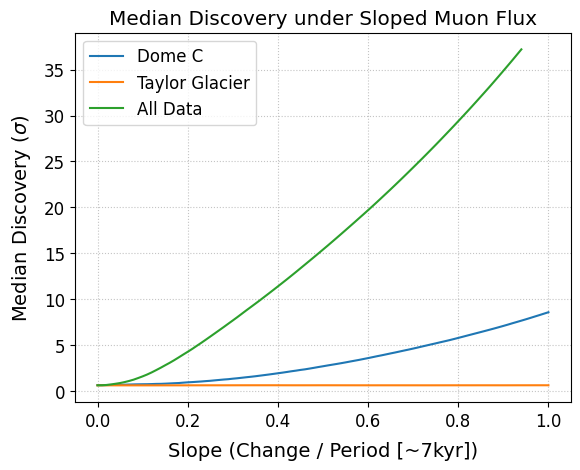

In [93]:
plt.plot(amps, np.median(sig_null, axis=0), label='Dome C')
plt.plot(amps, np.median(sig_null_TG, axis=0), label='Taylor Glacier')
plt.plot(amps, np.median(sig_null_all, axis=0), label='All Data')
plt.xlabel('Slope (Change / Period [~7kyr])')
plt.ylabel(r'Median Discovery ($\sigma$)')
plt.title('Median Discovery under Sloped Muon Flux')
plt.legend()
plt.show()

In [94]:
print('Dome C Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null[:,amps>0], axis=0),amps[amps>0]*100)))
print('Dome C Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.flip(np.median(sig_null[:,amps<0], axis=0)),np.flip(amps[amps<0]*100))))

Dome C Sensitivities: 40.7%(2σ), 53.4%(3σ), 63.9%(4σ), 73.2%(5σ)


ValueError: array of sample points is empty

In [78]:
print('Taylor Glacier Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_TG[:,amps>0], axis=0),amps[amps>0]*100)))
print('Taylor Glacier Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.flip(np.median(sig_null_TG[:,amps<0], axis=0)),np.flip(amps[amps<0]*100))))

Taylor Glacier Sensitivities: 100.0%(2σ), 100.0%(3σ), 100.0%(4σ), 100.0%(5σ)


ValueError: array of sample points is empty

In [79]:
print('All Data Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_all[:,amps>0], axis=0),amps[amps>0]*100)))
print('All Data Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.flip(np.median(sig_null_all[:,amps<0], axis=0)),np.flip(amps[amps<0]*100))))

All Data Sensitivities: 3.2%(2σ), 4.4%(3σ), 5.3%(4σ), 6.2%(5σ)


ValueError: array of sample points is empty

TypeError: Input z must be at least a (2, 2) shaped array, but has shape (1, 81)

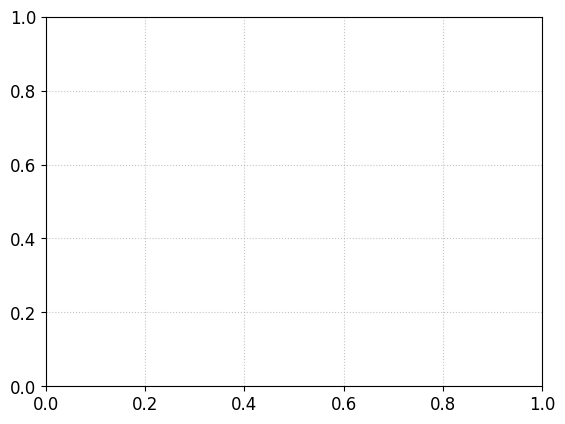

In [28]:
plt.contourf(amps, 1-(np.arange(N)+0.5)/N, np.sort(sig_null_all, axis=0).clip(max=6)-1, alpha=0.8, levels=np.arange(6), extend='min')
plt.colorbar()
plt.xlabel('Slope (Change / Period [~7kyr])')
plt.ylabel(r'Probability $\sigma \geq$Threshold')
plt.title('Discovery Probability under Linear Flux')
plt.show()

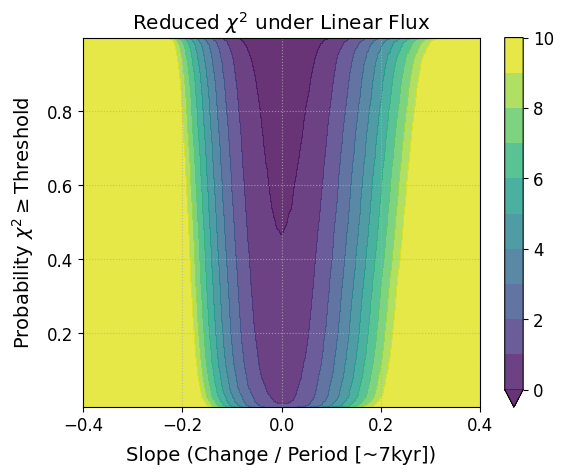

In [28]:
plt.contourf(amps, 1-(np.arange(N)+0.5)/N, np.sort(chi2_null_all/(len(z_samp)+len(z_samp_TG)-len(f_true)), axis=0).clip(max=11)-1, alpha=0.8, levels=np.arange(11), extend='min')
plt.colorbar()
plt.xlabel('Slope (Change / Period [~7kyr])')
plt.ylabel(r'Probability $\chi^2 \geq$Threshold')
plt.title(r'Reduced $\chi^2$ under Linear Flux')
plt.show()

In [29]:
N = 1000

flux_noise = np.abs(np.random.normal(0., 1., (N, 1, len(t))))

Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/10))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

print('Smoothing flux...')
flux_smooth = flux_noise @ Smooth
print('Normalizing flux...')
#flux_blur = flux_smooth @ Blur
#flux_scale = flux_smooth/np.std(flux_blur, axis=-1, keepdims=True)
#flux_scale = flux_smooth/np.sqrt(np.mean(((flux_blur - np.mean(flux_blur, axis=-1, keepdims=True))*np.exp(t*Prop.lambd))**2, axis=-1, keepdims=True))
#flux_scale = flux_smooth/np.mean(flux_smooth-flux_smooth[:,:,-1].reshape((-1,1,1)), axis=-1, keepdims=True)
flux_scale = flux_smooth/np.mean(flux_smooth-np.min(flux_smooth, axis=-1, keepdims=True), axis=-1, keepdims=True)
print('Done!')

Smoothing flux...
Normalizing flux...
Done!


In [30]:
da = 0.002
amps = np.arange(0.,0.2+da,da)
#amp = 0.05

flux_true = amps.reshape((1,-1,1))*flux_scale
flux_true += 1-flux_true[:,:,-1:]

#amps *= np.sqrt(np.sum(f_true**2))
#amps /= np.std(t_scale @ Blur)
#amps *= np.sqrt(12)
#amps *= 20

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

#flux_true = amp*t_scale + 1

CO_true = flux_true @ CO_response[0]
CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
# A note on the initial concentration of CO at Taylor Glacier
# The equilibrium value will be sensitive to changes in the muon flux before integration starts.
# I haven't yet thought through how to account for that, so for the moment this is ignored
CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

#Sigma = np.diag(CO_err**2)
#true_err = CO_true*rel_err
#true_cov = true_err.reshape((-1,1))*true_err.reshape((1,-1)) * rel_cov
#true_cov[:,np.arange(len(z_samp)),np.arange(len(z_samp))] = true_err**2
#true_cov_inv = np.linalg.inv(true_cov)

#true_err_TG = CO_true_TG*rel_err_TG
#true_cov_TG = true_err_TG.reshape((-1,1))*true_err_TG.reshape((1,-1)) * rel_cov_TG
#true_cov_TG[:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = true_err_TG**2
#true_cov_inv_TG = np.linalg.inv(true_cov_TG)

s = np.random.normal(1, rel_err, (N,1,len(z_samp)))
s_TG = np.random.normal(1, rel_err_TG, (N,1,len(z_samp_TG)))

#CO_exp = np.random.multivariate_normal(mean=CO_true, cov=true_cov)
#CO_exp_TG = np.random.multivariate_normal(mean=CO_true_TG, cov=true_cov_TG)
CO_exp = CO_true*s
CO_exp_TG = CO_true_TG*s_TG
CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

#CO_exp = CO_true
#CO_exp_TG = CO_true_TG
#CO_exp_all = CO_true_all

CO_err = np.abs(CO_exp * rel_err)
CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

#CO_exp_TG = CO_exp_TG_data
#CO_err_TG = CO_err_TG_data

#rel_err_all = np.concatenate(([rel_err]*len(z_samp), [rel_err_TG]*len(z_samp_TG)))

Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,len(z_samp))) * rel_cov
Sigma[:,:,np.arange(len(z_samp)),np.arange(len(z_samp))] = CO_err**2
Sigma_inv = np.linalg.inv(Sigma)

Sigma_TG = CO_err_TG.reshape((*CO_err_TG.shape,1))*CO_err_TG.reshape((*CO_err_TG.shape[:-1],1,len(z_samp_TG))) * rel_cov_TG
Sigma_TG[:,:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = CO_err_TG**2
Sigma_inv_TG = np.linalg.inv(Sigma_TG)

Sigma_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_all[:,:,:len(z_samp),:len(z_samp)] = Sigma
Sigma_all[:,:,len(z_samp):,len(z_samp):] = Sigma_TG
Sigma_inv_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_inv_all[:,:,:len(z_samp),:len(z_samp)] = Sigma_inv
Sigma_inv_all[:,:,len(z_samp):,len(z_samp):] = Sigma_inv_TG

In [31]:
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

f_hat_null = np.sum(np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv * CO_exp.reshape((*CO_exp.shape[:-1],1,len(z_samp))), axis=-1)
f_hat_null_TG = np.sum(np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG * CO_exp_TG.reshape((*CO_exp_TG.shape[:-1],1,len(z_samp_TG))), axis=-1)
f_hat_null_all = np.sum(np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all * CO_exp_all.reshape((*CO_exp_all.shape[:-1],1,len(z_samp)+len(z_samp_TG))), axis=-1)

Text(0.5, 1.0, 'Reconstructed Constant f-factors, True Amplitude = 0.1000')

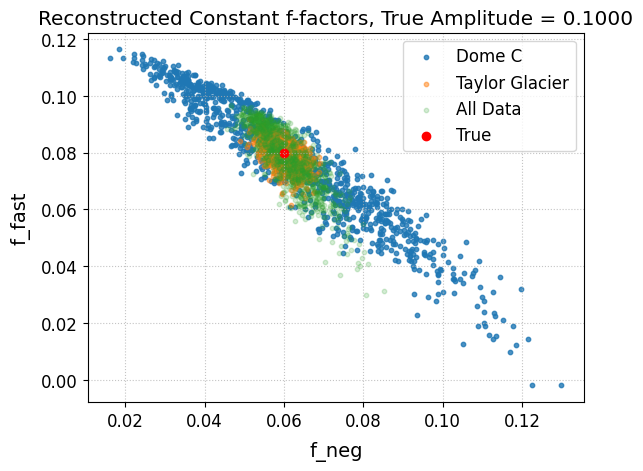

In [32]:
i=50
plt.scatter(f_hat_null[:,i,1], f_hat_null[:,i,0], s=10, alpha=0.8, label='Dome C')
plt.scatter(f_hat_null_TG[:,i,1],f_hat_null_TG[:,i,0], s=10, alpha=0.5, label='Taylor Glacier')
plt.scatter(f_hat_null_all[:,i,1],f_hat_null_all[:,i,0], s=10, alpha=0.2, label='All Data')
plt.scatter(f_true[1], f_true[0], c='r', label='True')
plt.xlabel('f_neg')
plt.ylabel('f_fast')
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
plt.legend()
plt.title('Reconstructed Constant f-factors, True Amplitude = {:.4f}'.format(amps[i]))

In [33]:
CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum(np.sum((CO_null - CO_exp).reshape((*CO_null.shape,1)) * Sigma_inv, axis=-2) *(CO_null - CO_exp), axis=-1)
p_null = stats.chi2.sf(chi2_null, len(z_samp)-len(f_true))
sig_null = stats.norm.isf(p_null/2.)

CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
chi2_null_TG = np.sum(np.sum((CO_null_TG - CO_exp_TG).reshape((*CO_null_TG.shape,1)) * Sigma_inv_TG, axis=-2) *(CO_null_TG - CO_exp_TG), axis=-1)
p_null_TG = stats.chi2.sf(chi2_null_TG, len(z_samp_TG)-len(f_true))
sig_null_TG = stats.norm.isf(p_null_TG/2.)

CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
chi2_null_all = np.sum(np.sum((CO_null_all - CO_exp_all).reshape((*CO_null_all.shape,1)) * Sigma_inv_all, axis=-2) *(CO_null_all - CO_exp_all), axis=-1)
p_null_all = stats.chi2.sf(chi2_null_all, len(z_samp)+len(z_samp_TG)-len(f_true))
sig_null_all = stats.norm.isf(p_null_all/2.)

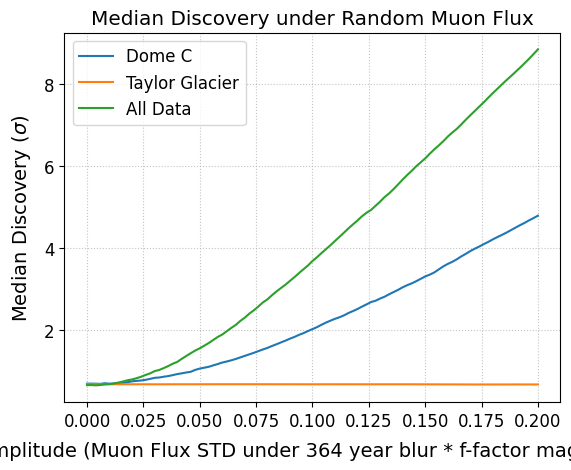

In [34]:
plt.plot(amps, np.median(sig_null, axis=0), label='Dome C')
plt.plot(amps, np.median(sig_null_TG, axis=0), label='Taylor Glacier')
plt.plot(amps, np.median(sig_null_all, axis=0), label='All Data')
plt.xlabel('Amplitude (Muon Flux STD under {:.0f} year blur * f-factor magnitude)'.format(Period/20))
plt.ylabel(r'Median Discovery ($\sigma$)')
plt.title('Median Discovery under Random Muon Flux')
plt.legend()
plt.show()

In [35]:
print('Dome C Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null, axis=0),amps)*100))

Dome C Sensitivities: 9.93%(2σ), 13.87%(3σ), 17.27%(4σ), 20.00%(5σ)


In [36]:
print('Taylor Glacier Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_TG, axis=0),amps)*100))

Taylor Glacier Sensitivities: 20.00%(2σ), 20.00%(3σ), 20.00%(4σ), 20.00%(5σ)


In [37]:
print('All Data Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_all, axis=0),amps)*100))

All Data Sensitivities: 6.28%(2σ), 8.55%(3σ), 10.66%(4σ), 12.74%(5σ)


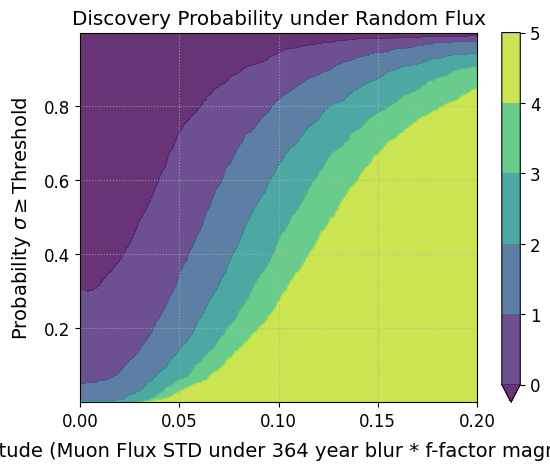

In [38]:
plt.contourf(amps, 1-(np.arange(N)+0.5)/N, np.sort(sig_null_all, axis=0).clip(max=6)-1, alpha=0.8, levels=np.arange(6), extend='min')
plt.colorbar()
plt.xlabel('Amplitude (Muon Flux STD under {:.0f} year blur * f-factor magnitude)'.format(Period/20))
plt.ylabel(r'Probability $\sigma \geq$Threshold')
plt.title('Discovery Probability under Random Flux')
plt.show()

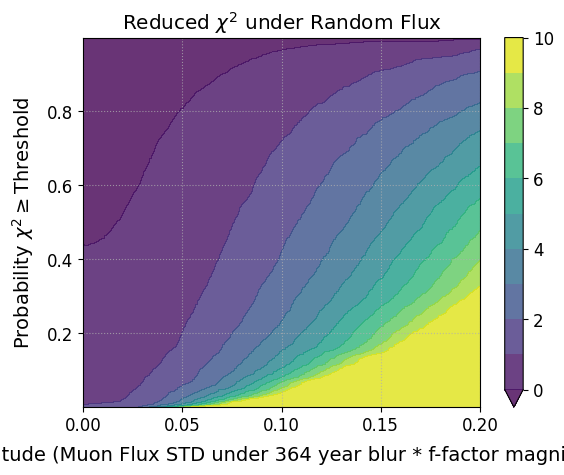

In [39]:
plt.contourf(amps, 1-(np.arange(N)+0.5)/N, np.sort(chi2_null_all/(len(z_samp)+len(z_samp_TG)-len(f_true)), axis=0).clip(max=11)-1, alpha=0.8, levels=np.arange(11), extend='min')
plt.colorbar()
plt.xlabel('Amplitude (Muon Flux STD under {:.0f} year blur * f-factor magnitude)'.format(Period/20))
plt.ylabel(r'Probability $\chi^2 \geq$Threshold')
plt.title(r'Reduced $\chi^2$ under Random Flux')
plt.show()

0.6205393970963478


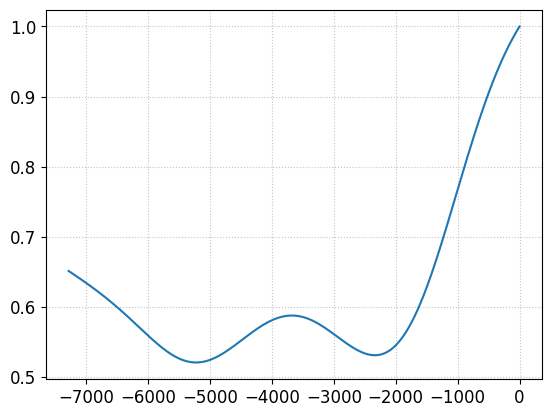

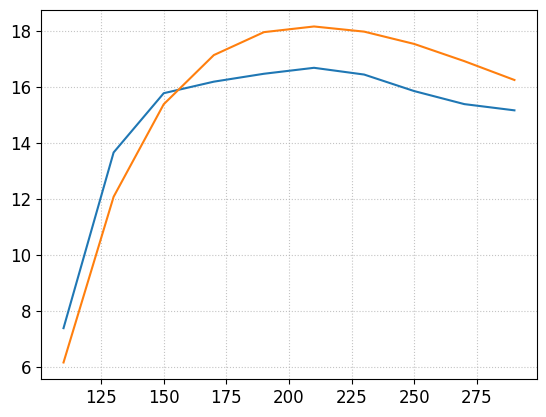

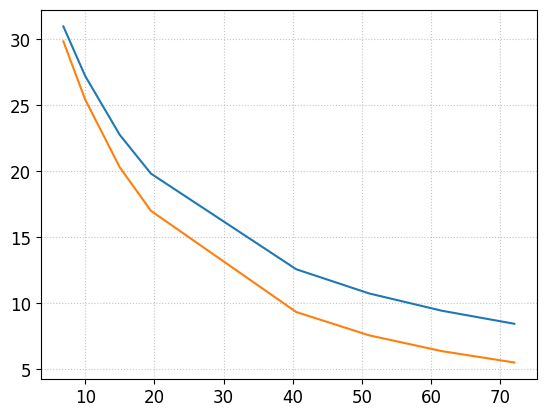

In [40]:
j = np.argmax(sig_null_all[:,i])
print(np.mean(flux_true[j,i]))
plt.plot(t, flux_true[j,i])
plt.show()
plt.plot(z_samp, CO_true[j,i])
plt.plot(z_samp, f_hat_null_all[j,i] @ C0[0])
plt.show()
plt.plot(z_samp_TG, CO_true_TG[j,i])
plt.plot(z_samp_TG, f_hat_null_all[j,i] @ C0_TG[0,0])
plt.show()

In [41]:
t_c = -4000
s = 50
flux_scale = (np.exp(-(t-t_c)**2/(2*s**2)) /np.sqrt(2*np.pi)/s).reshape((1,1,-1))
flux_scale /= np.mean(flux_scale-flux_scale[:,:,-1].reshape((*flux_scale.shape[:-1],1)), axis=-1, keepdims=True)

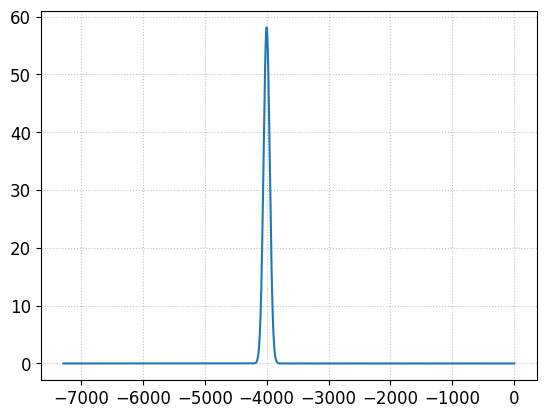

In [42]:
plt.plot(t, flux_scale[0,0])

In [43]:
da = 0.001
amps = np.arange(0.,0.1+da,da)
#amp = 0.05

flux_true = amps.reshape((1,-1,1))*flux_scale
flux_true += 1-flux_true[:,:,-1:]

#amps *= np.sqrt(np.sum(f_true**2))
#amps /= np.std(t_scale @ Blur)
#amps *= np.sqrt(12)
#amps *= 20

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

#flux_true = amp*t_scale + 1

CO_true = flux_true @ CO_response[0]
CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
# A note on the initial concentration of CO at Taylor Glacier
# The equilibrium value will be sensitive to changes in the muon flux before integration starts.
# I haven't yet thought through how to account for that, so for the moment this is ignored
CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

#Sigma = np.diag(CO_err**2)
#true_err = CO_true*rel_err
#true_cov = true_err.reshape((-1,1))*true_err.reshape((1,-1)) * rel_cov
#true_cov[:,np.arange(len(z_samp)),np.arange(len(z_samp))] = true_err**2
#true_cov_inv = np.linalg.inv(true_cov)

#true_err_TG = CO_true_TG*rel_err_TG
#true_cov_TG = true_err_TG.reshape((-1,1))*true_err_TG.reshape((1,-1)) * rel_cov_TG
#true_cov_TG[:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = true_err_TG**2
#true_cov_inv_TG = np.linalg.inv(true_cov_TG)

s = np.random.normal(1, rel_err, (N,1,len(z_samp)))
s_TG = np.random.normal(1, rel_err_TG, (N,1,len(z_samp_TG)))

#CO_exp = np.random.multivariate_normal(mean=CO_true, cov=true_cov)
#CO_exp_TG = np.random.multivariate_normal(mean=CO_true_TG, cov=true_cov_TG)
CO_exp = CO_true*s
CO_exp_TG = CO_true_TG*s_TG
CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

#CO_exp = CO_true
#CO_exp_TG = CO_true_TG
#CO_exp_all = CO_true_all

CO_err = np.abs(CO_exp * rel_err)
CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

#CO_exp_TG = CO_exp_TG_data
#CO_err_TG = CO_err_TG_data

#rel_err_all = np.concatenate(([rel_err]*len(z_samp), [rel_err_TG]*len(z_samp_TG)))

Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,len(z_samp))) * rel_cov
Sigma[:,:,np.arange(len(z_samp)),np.arange(len(z_samp))] = CO_err**2
Sigma_inv = np.linalg.inv(Sigma)

Sigma_TG = CO_err_TG.reshape((*CO_err_TG.shape,1))*CO_err_TG.reshape((*CO_err_TG.shape[:-1],1,len(z_samp_TG))) * rel_cov_TG
Sigma_TG[:,:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = CO_err_TG**2
Sigma_inv_TG = np.linalg.inv(Sigma_TG)

Sigma_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_all[:,:,:len(z_samp),:len(z_samp)] = Sigma
Sigma_all[:,:,len(z_samp):,len(z_samp):] = Sigma_TG
Sigma_inv_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_inv_all[:,:,:len(z_samp),:len(z_samp)] = Sigma_inv
Sigma_inv_all[:,:,len(z_samp):,len(z_samp):] = Sigma_inv_TG

In [44]:
C0 = np.sum(C_response, axis=-2)
C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

f_hat_null = np.sum(np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv * CO_exp.reshape((*CO_exp.shape[:-1],1,len(z_samp))), axis=-1)
f_hat_null_TG = np.sum(np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG * CO_exp_TG.reshape((*CO_exp_TG.shape[:-1],1,len(z_samp_TG))), axis=-1)
f_hat_null_all = np.sum(np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all * CO_exp_all.reshape((*CO_exp_all.shape[:-1],1,len(z_samp)+len(z_samp_TG))), axis=-1)

Text(0.5, 1.0, 'Reconstructed Constant f-factors, True Amplitude = 0.0500')

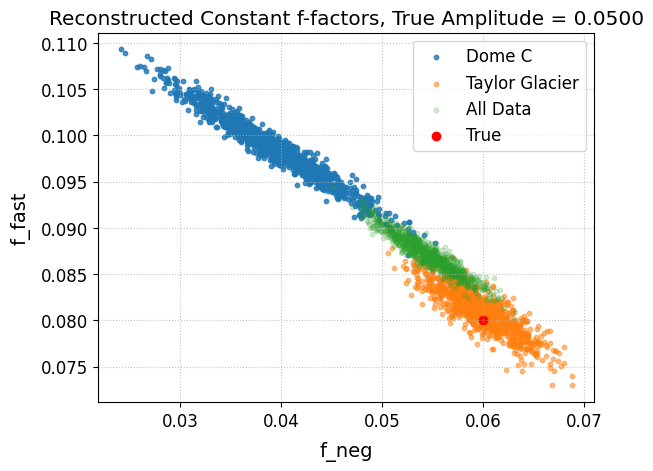

In [45]:
i=50
plt.scatter(f_hat_null[:,i,1], f_hat_null[:,i,0], s=10, alpha=0.8, label='Dome C')
plt.scatter(f_hat_null_TG[:,i,1],f_hat_null_TG[:,i,0], s=10, alpha=0.5, label='Taylor Glacier')
plt.scatter(f_hat_null_all[:,i,1],f_hat_null_all[:,i,0], s=10, alpha=0.2, label='All Data')
plt.scatter(f_true[1], f_true[0], c='r', label='True')
plt.xlabel('f_neg')
plt.ylabel('f_fast')
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
plt.legend()
plt.title('Reconstructed Constant f-factors, True Amplitude = {:.4f}'.format(amps[i]))

In [46]:
CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
chi2_null = np.sum(np.sum((CO_null - CO_exp).reshape((*CO_null.shape,1)) * Sigma_inv, axis=-2) *(CO_null - CO_exp), axis=-1)
p_null = stats.chi2.sf(chi2_null, len(z_samp)-len(f_true))
sig_null = stats.norm.isf(p_null/2.)

CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
chi2_null_TG = np.sum(np.sum((CO_null_TG - CO_exp_TG).reshape((*CO_null_TG.shape,1)) * Sigma_inv_TG, axis=-2) *(CO_null_TG - CO_exp_TG), axis=-1)
p_null_TG = stats.chi2.sf(chi2_null_TG, len(z_samp_TG)-len(f_true))
sig_null_TG = stats.norm.isf(p_null_TG/2.)

CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
chi2_null_all = np.sum(np.sum((CO_null_all - CO_exp_all).reshape((*CO_null_all.shape,1)) * Sigma_inv_all, axis=-2) *(CO_null_all - CO_exp_all), axis=-1)
p_null_all = stats.chi2.sf(chi2_null_all, len(z_samp)+len(z_samp_TG)-len(f_true))
sig_null_all = stats.norm.isf(p_null_all/2.)

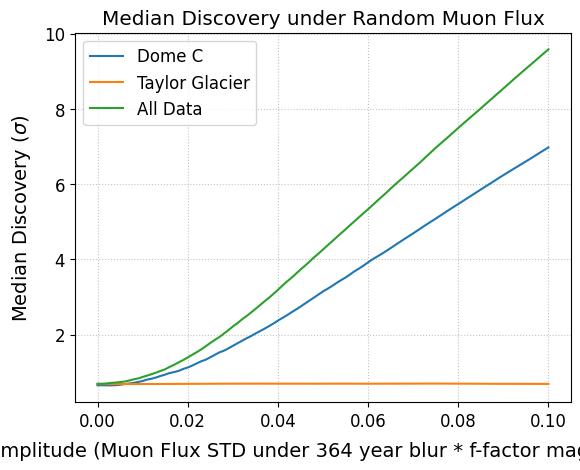

In [47]:
plt.plot(amps, np.median(sig_null, axis=0), label='Dome C')
plt.plot(amps, np.median(sig_null_TG, axis=0), label='Taylor Glacier')
plt.plot(amps, np.median(sig_null_all, axis=0), label='All Data')
plt.xlabel('Amplitude (Muon Flux STD under {:.0f} year blur * f-factor magnitude)'.format(Period/20))
plt.ylabel(r'Median Discovery ($\sigma$)')
plt.title('Median Discovery under Random Muon Flux')
plt.legend()
plt.show()

In [48]:
np.interp([2,3,4,5],np.median(sig_null, axis=0),amps)

array([0.03458937, 0.04818025, 0.06098589, 0.07390733])

In [49]:
print('Dome C Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null, axis=0),amps)*100))

Dome C Sensitivities: 3.5%(2σ), 4.8%(3σ), 6.1%(4σ), 7.4%(5σ)


In [50]:
print('Taylor Glacier Sensitivities: {:.0f}%(2σ), {:.0f}%(3σ), {:.0f}%(4σ), {:.0f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_TG, axis=0),amps)*100))

Taylor Glacier Sensitivities: 10%(2σ), 10%(3σ), 10%(4σ), 10%(5σ)


In [51]:
print('All Data Sensitivities: {:.1f}%(2σ), {:.1f}%(3σ), {:.1f}%(4σ), {:.1f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_null_all, axis=0),amps)*100))

All Data Sensitivities: 2.8%(2σ), 3.8%(3σ), 4.8%(4σ), 5.7%(5σ)


In [52]:
np.std(CO_err, axis=(0,1))/np.mean(CO_err, axis=(0,1))

array([0.0207674 , 0.02034469, 0.01985494, 0.0193103 , 0.01986205,
       0.04527554, 0.06361432, 0.04713599, 0.03854791, 0.03271412])

In [53]:
def get_err(CO_exp, rel_err = 0.02, rel_cov = 0.):
    CO_err = np.abs(CO_exp * rel_err)

    Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,CO_err.shape[-1])) * rel_cov
    Sigma[np.arange(CO_err.shape[-1]),np.arange(CO_err.shape[-1])] = CO_err**2
    Sigma_inv = np.linalg.inv(Sigma)
    
    return CO_err, Sigma, Sigma_inv

In [54]:
CO_base = np.sum(CO_response[0], axis=-2)
CO_base_TG = np.sum(CO_response_TG[0,0], axis=-2)
CO_base_all = np.concatenate((CO_base, CO_base_TG), axis=-1)

rel_err = 0.02
rel_cov = 0. # correlation of experimental errors

rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
rel_cov_TG = 0.

CO_base_err, Sigma_base, Sigma_base_inv = get_err(CO_base, rel_err, rel_cov)
CO_base_err_TG, Sigma_base_TG, Sigma_base_inv_TG = get_err(CO_base_TG, rel_err_TG, rel_cov_TG)

CO_base_err_all = np.concatenate((CO_base_err, CO_base_err_TG), axis=-1)

Sigma_base_all = np.zeros((*CO_base_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_base_all[:len(z_samp),:len(z_samp)] = Sigma_base
Sigma_base_all[len(z_samp):,len(z_samp):] = Sigma_base_TG
Sigma_base_inv_all = np.zeros((*CO_base_err_all.shape,len(z_samp)+len(z_samp_TG)))
Sigma_base_inv_all[:len(z_samp),:len(z_samp)] = Sigma_base_inv
Sigma_base_inv_all[len(z_samp):,len(z_samp):] = Sigma_base_inv_TG

C0 = np.sum(C_response, axis=-2)
C0_TG = (np.sum(C_response_TG, axis=-2) + C_init_TG)
C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

F_hat = np.linalg.inv(C0 @ Sigma_base_inv @ T(C0)) @ C0 @ Sigma_base_inv
F_hat_TG = np.linalg.inv(C0_TG @ Sigma_base_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_base_inv_TG
F_hat_all = np.linalg.inv(C0_all @ Sigma_base_inv_all @ T(C0_all)) @ C0_all @ Sigma_base_inv_all

In [55]:
Sigma_fit_inv_all = T(np.identity(len(z_samp) + len(z_samp_TG)) - T(C0_all)[0,0] @ F_hat_all[0,0]) @ Sigma_base_inv_all @ (np.identity(len(z_samp) + len(z_samp_TG)) - T(C0_all)[0,0] @ F_hat_all[0,0])

In [56]:
Sigma_fit_inv_all.shape

(18, 18)

In [57]:
centers = np.arange(t[0],t[-1]+50,50)
s = np.arange(50,2000+50,50)
flux_var = (np.exp(-(t.reshape((1,1,-1))-centers.reshape((1,-1,1)))**2/(2*s.reshape((-1,1,1))**2)) /np.sqrt(2*np.pi)/s.reshape((-1,1,1)))
#flux_var /= np.mean(flux_var-flux_var[:,:,-1].reshape((*flux_var.shape[:-1],1)), axis=-1, keepdims=True)
#flux_var -= flux_var[:,:,-1].reshape((*flux_var.shape[:-1],1))
flux_var /= np.mean(flux_var, axis=-1, keepdims=True)

CO_var = flux_var @ CO_response[0]
CO_var_TG = flux_var @ CO_response_TG[0,0]# + CO_init_TG[0,0]#*flux_true[0]
CO_var_all = np.concatenate((CO_var, CO_var_TG), axis=-1)

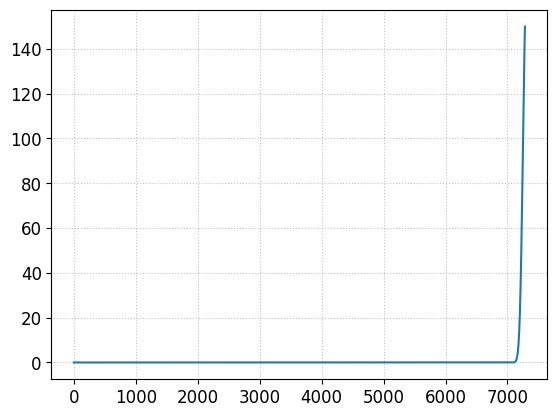

In [58]:
plt.plot(flux_var[0,-1])

In [59]:
sigs = [2,3,4,5]
chi2_sig_all = np.array([stats.chi2.isf(2*stats.norm.sf(sig), len(z_samp)+len(z_samp_TG)-len(f_true)) for sig in sigs])-(len(z_samp)+len(z_samp_TG)-len(f_true)-1)

In [60]:
chi2_var = np.sum(CO_var_all @ Sigma_fit_inv_all * CO_var_all, axis=-1)

Text(0.5, 1.0, 'Gaussian Burst Sensitivity (Dome C + Taylor) [Width = 1000 years]')

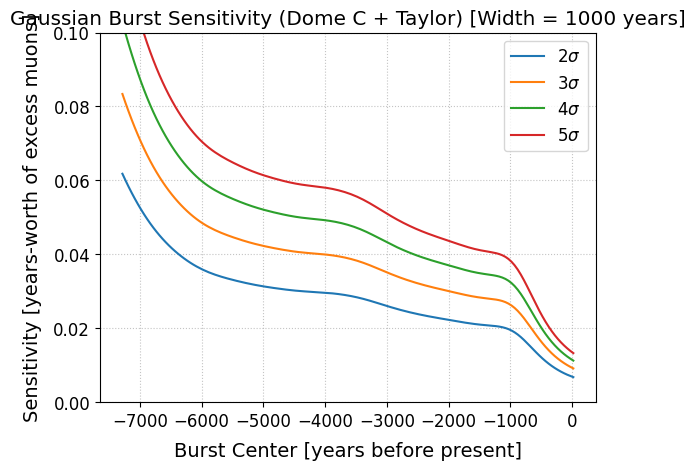

In [61]:
j = 9
for i in range(len(sigs)):
    plt.plot(centers, np.sqrt(chi2_sig_all[i]/chi2_var[j]), label=r'{}$\sigma$'.format(sigs[i]))
plt.xlabel('Burst Center [years before present]')
plt.ylabel('Sensitivity [years-worth of excess muons]')
plt.ylim(0,0.1)
plt.legend()
plt.title('Gaussian Burst Sensitivity (Dome C + Taylor) [Width = {} years]'.format(s[j]*2))

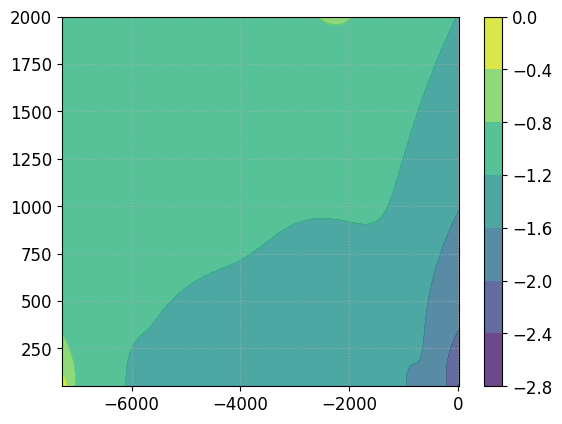

In [62]:
plt.contourf(centers, s, np.log10(np.sqrt(chi2_sig_all[-1]/chi2_var)), alpha=0.8)
plt.colorbar()

In [63]:
chi2_var.shape

(40, 147)

In [64]:
CO_base_all @ Sigma_base_inv_all @ CO_base_all

np.float64(34519.2163047555)

In [65]:
np.median(np.std(flux_var[0], axis=-1))/np.median(np.std(flux_var[9], axis=-1))

np.float64(3.5901852148492615)

In [66]:
np.std(t_scale @ Blur)/np.max(np.std(flux_var[0] @ Blur, axis=-1))

np.float64(0.10354435293552522)

In [67]:
-np.sum(t_scale)

np.float64(3641.5)

In [68]:
np.max(np.std(flux_var[0] @ Blur, axis=-1))*410

np.float64(1121.2641497371976)

In [100]:
np.std((0*t_scale+1) @ Blur)*0.22

np.float64(2.989639274193491e-16)

In [102]:
flux_linear = t_scale
#flux_linear /= -np.mean(t_scale)
flux_linear /= np.std(t_scale @ Blur)

N = 1000

flux_noise = np.random.normal(0., 1., (N, 1, len(t)))

Smooth = np.exp(-((t.reshape((-1,1))-t.reshape((1,-1)))/(Period/10))**2/2)
Smooth /= np.sum(Smooth, axis=0, keepdims=True)

print('Smoothing flux...')
flux_smooth = flux_noise @ Smooth
print('Normalizing flux...')
#flux_rand = flux_smooth/np.mean(flux_smooth-np.min(flux_smooth, axis=-1, keepdims=True), axis=-1, keepdims=True)
flux_rand = flux_smooth/np.std(flux_smooth @ Blur, axis=-1, keepdims=True)

t_c = -4000
s = 50
flux_burst = (np.exp(-(t-t_c)**2/(2*s**2)) /np.sqrt(2*np.pi)/s).reshape((1,1,-1))
#flux_burst /= np.mean(flux_burst-flux_burst[:,:,-1].reshape((*flux_burst.shape[:-1],1)), axis=-1, keepdims=True)
flux_burst /= np.std(flux_burst @ Blur, axis=-1, keepdims=True)

Smoothing flux...
Normalizing flux...


In [103]:
def get_CO(flux_true):
    rel_err = 0.02
    rel_cov = 0. # correlation of experimental errors

    rel_err_TG = np.mean(CO_err_TG_data/CO_exp_TG_data)
    rel_cov_TG = 0.
    
    CO_true = flux_true @ CO_response[0]
    CO_true_TG = flux_true @ CO_response_TG[0,0] + CO_init_TG[0,0]#*flux_true[0]
    # A note on the initial concentration of CO at Taylor Glacier
    # The equilibrium value will be sensitive to changes in the muon flux before integration starts.
    # I haven't yet thought through how to account for that, so for the moment this is ignored
    CO_true_all = np.concatenate((CO_true, CO_true_TG), axis=-1)

    s = np.random.normal(1, rel_err, (N,1,len(z_samp)))
    s_TG = np.random.normal(1, rel_err_TG, (N,1,len(z_samp_TG)))

    CO_exp = CO_true*s
    CO_exp_TG = CO_true_TG*s_TG
    CO_exp_all = np.concatenate((CO_exp, CO_exp_TG), axis=-1)

    CO_err = np.abs(CO_exp * rel_err)
    CO_err_TG = np.abs(CO_exp_TG * rel_err_TG)
    CO_err_all = np.concatenate((CO_err, CO_err_TG), axis=-1)

    Sigma = CO_err.reshape((*CO_err.shape, 1))*CO_err.reshape((*CO_err.shape[:-1],1,len(z_samp))) * rel_cov
    Sigma[:,:,np.arange(len(z_samp)),np.arange(len(z_samp))] = CO_err**2
    Sigma_inv = np.linalg.inv(Sigma)

    Sigma_TG = CO_err_TG.reshape((*CO_err_TG.shape,1))*CO_err_TG.reshape((*CO_err_TG.shape[:-1],1,len(z_samp_TG))) * rel_cov_TG
    Sigma_TG[:,:,np.arange(len(z_samp_TG)),np.arange(len(z_samp_TG))] = CO_err_TG**2
    Sigma_inv_TG = np.linalg.inv(Sigma_TG)

    Sigma_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
    Sigma_all[:,:,:len(z_samp),:len(z_samp)] = Sigma
    Sigma_all[:,:,len(z_samp):,len(z_samp):] = Sigma_TG
    Sigma_inv_all = np.zeros((*CO_err_all.shape,len(z_samp)+len(z_samp_TG)))
    Sigma_inv_all[:,:,:len(z_samp),:len(z_samp)] = Sigma_inv
    Sigma_inv_all[:,:,len(z_samp):,len(z_samp):] = Sigma_inv_TG
    
    return CO_true, CO_true_TG, CO_true_all, CO_exp, CO_exp_TG, CO_exp_all, CO_err, CO_err_TG, CO_err_all, Sigma, Sigma_TG, Sigma_all, Sigma_inv, Sigma_inv_TG, Sigma_inv_all

In [104]:
da = 0.002
amps = np.arange(0.,0.3+da,da)

flux_true_linear = amps.reshape((1,-1,1))*flux_linear
flux_true_linear += 1-flux_true_linear[:,:,-1:]

flux_true_rand = amps.reshape((1,-1,1))*flux_rand
flux_true_rand += 1-flux_true_rand[:,:,-1:]

flux_true_burst = amps.reshape((1,-1,1))*flux_burst
flux_true_burst += 1-flux_true_burst[:,:,-1:]

#flux_true = amp*t_scale + 1

CO_true_linear, CO_true_linear_TG, CO_true_linear_all, CO_exp_linear, CO_exp_linear_TG, CO_exp_linear_all, CO_err_linear, CO_err_linear_TG, CO_err_linear_all, Sigma_linear, Sigma_linear_TG, Sigma_linear_all, Sigma_inv_linear, Sigma_inv_linear_TG, Sigma_inv_linear_all = get_CO(flux_true_linear)

In [105]:
CO_true_rand, CO_true_rand_TG, CO_true_rand_all, CO_exp_rand, CO_exp_rand_TG, CO_exp_rand_all, CO_err_rand, CO_err_rand_TG, CO_err_rand_all, Sigma_rand, Sigma_rand_TG, Sigma_rand_all, Sigma_inv_rand, Sigma_inv_rand_TG, Sigma_inv_rand_all = get_CO(flux_true_rand)

In [106]:
CO_true_burst, CO_true_burst_TG, CO_true_burst_all, CO_exp_burst, CO_exp_burst_TG, CO_exp_burst_all, CO_err_burst, CO_err_burst_TG, CO_err_burst_all, Sigma_burst, Sigma_burst_TG, Sigma_burst_all, Sigma_inv_burst, Sigma_inv_burst_TG, Sigma_inv_burst_all = get_CO(flux_true_burst)

In [107]:
def get_f_hat(CO_exp, CO_exp_TG, CO_exp_all, Sigma_inv, Sigma_inv_TG, Sigma_inv_all):
    C0 = np.sum(C_response, axis=-2)
    C0_TG = np.sum(C_response_TG, axis=-2) + C_init_TG
    C0_all = np.concatenate((np.expand_dims(C0, axis=0), C0_TG), axis=-1)

    f_hat = np.sum(np.linalg.inv(C0 @ Sigma_inv @ T(C0)) @ C0 @ Sigma_inv * CO_exp.reshape((*CO_exp.shape[:-1],1,len(z_samp))), axis=-1)
    f_hat_TG = np.sum(np.linalg.inv(C0_TG @ Sigma_inv_TG @ T(C0_TG)) @ C0_TG @ Sigma_inv_TG * CO_exp_TG.reshape((*CO_exp_TG.shape[:-1],1,len(z_samp_TG))), axis=-1)
    f_hat_all = np.sum(np.linalg.inv(C0_all @ Sigma_inv_all @ T(C0_all)) @ C0_all @ Sigma_inv_all * CO_exp_all.reshape((*CO_exp_all.shape[:-1],1,len(z_samp)+len(z_samp_TG))), axis=-1)
    
    return f_hat, f_hat_TG, f_hat_all

In [108]:
f_hat_linear, f_hat_linear_TG, f_hat_linear_all = get_f_hat(CO_exp_linear, CO_exp_linear_TG, CO_exp_linear_all, Sigma_inv_linear, Sigma_inv_linear_TG, Sigma_inv_linear_all)

In [109]:
f_hat_rand, f_hat_rand_TG, f_hat_rand_all = get_f_hat(CO_exp_rand, CO_exp_rand_TG, CO_exp_rand_all, Sigma_inv_rand, Sigma_inv_rand_TG, Sigma_inv_rand_all)

In [110]:
f_hat_burst, f_hat_burst_TG, f_hat_burst_all = get_f_hat(CO_exp_burst, CO_exp_burst_TG, CO_exp_burst_all, Sigma_inv_burst, Sigma_inv_burst_TG, Sigma_inv_burst_all)

In [111]:
def get_chi2(CO_exp, CO_exp_TG, CO_exp_all, f_hat_null, f_hat_null_TG, f_hat_null_all, Sigma_inv, Sigma_inv_TG, Sigma_inv_all):
    CO_null = np.sum(f_hat_null.reshape((*np.shape(f_hat_null),1)) * C0, axis=-2) 
    chi2_null = np.sum(np.sum((CO_null - CO_exp).reshape((*CO_null.shape,1)) * Sigma_inv, axis=-2) *(CO_null - CO_exp), axis=-1)
    p_null = stats.chi2.sf(chi2_null, len(z_samp)-len(f_true))
    sig_null = stats.norm.isf(p_null/2.)

    CO_null_TG = np.sum(f_hat_null_TG.reshape((*np.shape(f_hat_null_TG),1)) * C0_TG, axis=-2) 
    chi2_null_TG = np.sum(np.sum((CO_null_TG - CO_exp_TG).reshape((*CO_null_TG.shape,1)) * Sigma_inv_TG, axis=-2) *(CO_null_TG - CO_exp_TG), axis=-1)
    p_null_TG = stats.chi2.sf(chi2_null_TG, len(z_samp_TG)-len(f_true))
    sig_null_TG = stats.norm.isf(p_null_TG/2.)

    CO_null_all = np.sum(f_hat_null_all.reshape((*np.shape(f_hat_null_all),1)) * C0_all, axis=-2) 
    chi2_null_all = np.sum(np.sum((CO_null_all - CO_exp_all).reshape((*CO_null_all.shape,1)) * Sigma_inv_all, axis=-2) *(CO_null_all - CO_exp_all), axis=-1)
    p_null_all = stats.chi2.sf(chi2_null_all, len(z_samp)+len(z_samp_TG)-len(f_true))
    sig_null_all = stats.norm.isf(p_null_all/2.)
    
    return CO_null, chi2_null, p_null, sig_null, CO_null_TG, chi2_null_TG, p_null_TG, sig_null_TG, CO_null_all, chi2_null_all, p_null_all, sig_null_all

In [112]:
CO_linear, chi2_linear, p_linear, sig_linear, CO_linear_TG, chi2_linear_TG, p_linear_TG, sig_linear_TG, CO_linear_all, chi2_linear_all, p_linear_all, sig_linear_all = get_chi2(CO_exp_linear, CO_exp_linear_TG, CO_exp_linear_all, f_hat_linear, f_hat_linear_TG, f_hat_linear_all, Sigma_inv_linear, Sigma_inv_linear_TG, Sigma_inv_linear_all)

In [113]:
CO_rand, chi2_rand, p_rand, sig_rand, CO_rand_TG, chi2_rand_TG, p_rand_TG, sig_rand_TG, CO_rand_all, chi2_rand_all, p_rand_all, sig_rand_all = get_chi2(CO_exp_rand, CO_exp_rand_TG, CO_exp_rand_all, f_hat_rand, f_hat_rand_TG, f_hat_rand_all, Sigma_inv_rand, Sigma_inv_rand_TG, Sigma_inv_rand_all)

In [114]:
CO_burst, chi2_burst, p_burst, sig_burst, CO_burst_TG, chi2_burst_TG, p_burst_TG, sig_burst_TG, CO_burst_all, chi2_burst_all, p_burst_all, sig_burst_all = get_chi2(CO_exp_burst, CO_exp_burst_TG, CO_exp_burst_all, f_hat_burst, f_hat_burst_TG, f_hat_burst_all, Sigma_inv_burst, Sigma_inv_burst_TG, Sigma_inv_burst_all)

0.1


(0.5, 1.5)

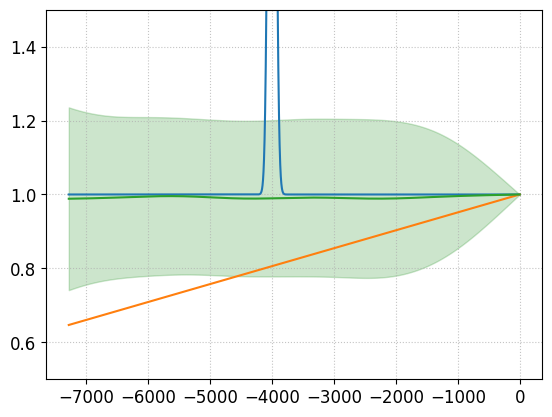

In [115]:
i=50
print(amps[i])
#plt.plot(t, flux_true_rand[:,i].T, alpha=0.1, c='green')
plt.fill_between(t, np.mean(flux_true_rand[:,i], axis=0)-np.std(flux_true_rand[:,i], axis=0), np.mean(flux_true_rand[:,i], axis=0)+np.std(flux_true_rand[:,i], axis=0), alpha=0.2, color='green')
plt.plot(t, flux_true_burst[0,i])
plt.plot(t, flux_true_linear[0,i])
plt.plot(t, np.mean(flux_true_rand[:,i], axis=0))
plt.ylim(0.5,1.5)

In [116]:
amp_5sig_burst = np.interp(5, np.median(sig_burst_all, axis=0), amps)
amp_5sig_linear = np.interp(5, np.median(sig_linear_all, axis=0), amps)
amp_5sig_rand = np.array([np.interp(5,s,amps) for s in sig_rand_all])

flux_5sig_burst = flux_burst*amp_5sig_burst
flux_5sig_burst += 1-flux_5sig_burst[:,:,-1].reshape((*flux_5sig_burst.shape[:-1],1))

flux_5sig_linear = flux_linear.reshape((1,1,-1))*amp_5sig_linear
flux_5sig_linear += 1-flux_5sig_linear[:,:,-1].reshape((*flux_5sig_linear.shape[:-1],1))

flux_5sig_rand = flux_rand*amp_5sig_rand.reshape((-1,1,1))
flux_5sig_rand += 1-flux_5sig_rand[:,:,-1].reshape((*flux_5sig_rand.shape[:-1],1))

In [117]:
flux_5sig_burst.max()

np.float64(4.261387934278116)

0.1


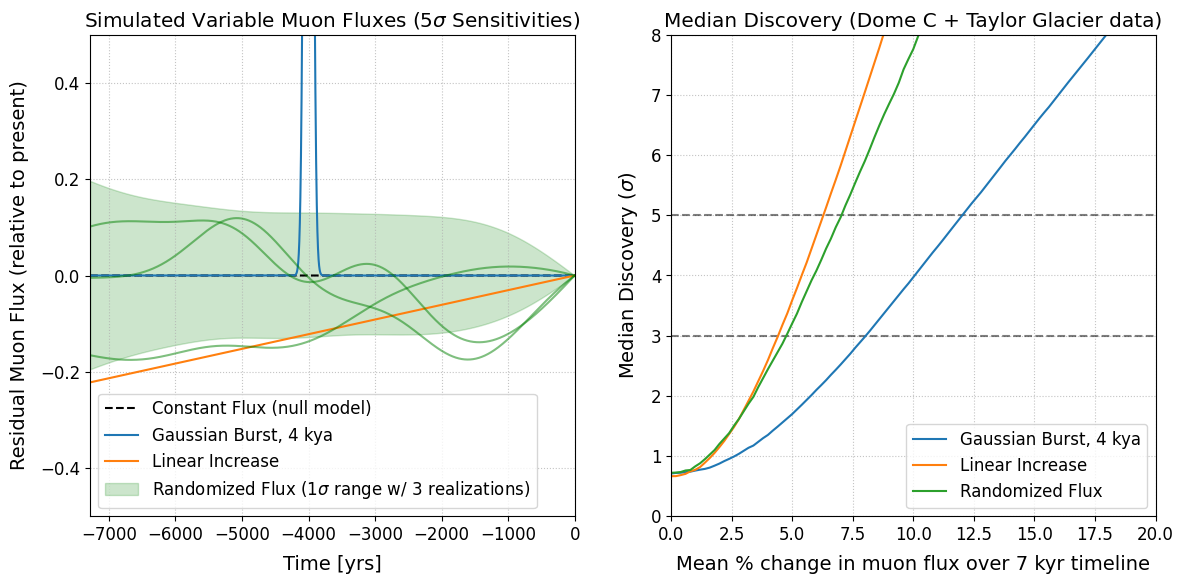

In [118]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

i=50
print(amps[i])
#plt.plot(t, flux_true_rand[:,i].T, alpha=0.1, c='green')
ax1.plot(t, t*0, label='Constant Flux (null model)', c='k', ls='--')
ax1.plot(t, flux_5sig_burst[0,0]-1, label='Gaussian Burst, 4 kya')
ax1.plot(t, flux_5sig_linear[0,0]-1, label='Linear Increase')
ax1.fill_between(t, np.mean(flux_5sig_rand[:,0], axis=0)-np.std(flux_5sig_rand[:,0], axis=0)-1, np.mean(flux_5sig_rand[:,0], axis=0)+np.std(flux_5sig_rand[:,0], axis=0)-1, alpha=0.2, color='green', label=r'Randomized Flux (1$\sigma$ range w/ 3 realizations)')
for j in [1,4,12]:
    ax1.plot(t, flux_5sig_rand[j,0]-1, c='green', alpha=0.5)
ax1.set(
    xlabel = 'Time [yrs]',
    ylabel = 'Residual Muon Flux (relative to present)',
    xlim = (t_bins[0],t_bins[-1]),
    ylim = (-0.5,0.5),
    title=r'Simulated Variable Muon Fluxes (5$\sigma$ Sensitivities)',
)
ax1.legend()

ax2.axhline(3, ls='--', c='k', alpha=0.5)
ax2.axhline(5, ls='--', c='k', alpha=0.5)
ax2.plot(amps*100, np.median(sig_burst_all, axis=0), label='Gaussian Burst, 4 kya')
ax2.plot(amps*100, np.median(sig_linear_all, axis=0), label='Linear Increase')
ax2.plot(amps*100, np.median(sig_rand_all, axis=0), label='Randomized Flux')
ax2.set(
    xlabel = 'Mean % change in muon flux over 7 kyr timeline',
    ylabel = r'Median Discovery ($\sigma$)',
    xlim= (0,20),
    ylim = (0,8),
    title = 'Median Discovery (Dome C + Taylor Glacier data)',
)
ax2.legend()
plt.show()

In [119]:
np.max(flux_true_burst[:,28])

np.float64(2.5189246142517554)

In [120]:
amps[28]

np.float64(0.056)

In [121]:
print('Dome C Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_burst, axis=0),amps)*100))

Dome C Sensitivities: 6.95%(2σ), 9.89%(3σ), 12.68%(4σ), 15.39%(5σ)


In [122]:
print('All Data Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_burst_all, axis=0),amps)*100))

All Data Sensitivities: 5.77%(2σ), 8.04%(3σ), 10.06%(4σ), 12.02%(5σ)


In [123]:
print('Dome C Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_linear, axis=0),amps)*100))

Dome C Sensitivities: 11.42%(2σ), 15.01%(3σ), 17.99%(4σ), 20.67%(5σ)


In [124]:
print('All Data Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_linear_all, axis=0),amps)*100))

All Data Sensitivities: 3.31%(2σ), 4.42%(3σ), 5.39%(4σ), 6.29%(5σ)


In [125]:
print('Dome C Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_rand, axis=0),amps)*100))

Dome C Sensitivities: 5.37%(2σ), 7.56%(3σ), 9.60%(4σ), 11.54%(5σ)


In [126]:
print('All Data Sensitivities: {:.2f}%(2σ), {:.2f}%(3σ), {:.2f}%(4σ), {:.2f}%(5σ)'.format(*np.interp([2,3,4,5],np.median(sig_rand_all, axis=0),amps)*100))

All Data Sensitivities: 3.42%(2σ), 4.76%(3σ), 5.90%(4σ), 7.03%(5σ)


In [95]:
CO_response_all = np.concatenate((CO_response[0], CO_response_TG[0,0]), axis=-1)

In [96]:
f_noise = np.random.rand(len(t))

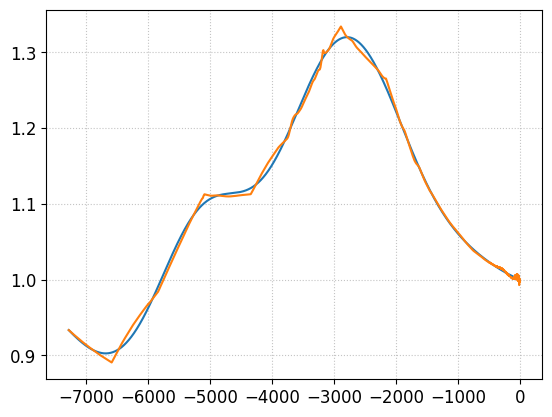

In [97]:
y = flux_true_rand[13,100]
#y = f_noise
plt.plot(t, y)
plt.plot(t, CO_response_all @ np.linalg.inv(CO_response_all.T @ CO_response_all) @ CO_response_all.T @ (y - y[0]) + y[0])
#plt.plot(t, CO_response_all @ np.linalg.inv(CO_response_all.T @ CO_response_all) @ CO_response_all.T @ (y - np.mean(y)) + np.mean(y))

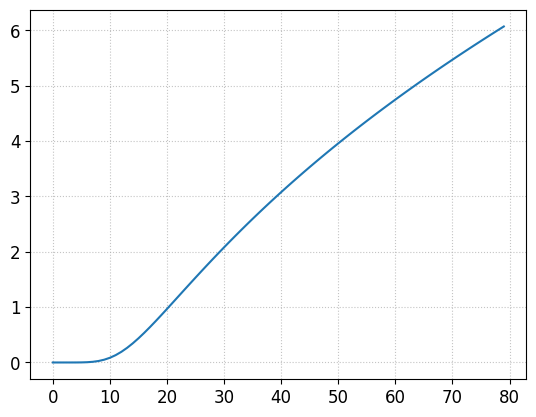

In [98]:
c2 = np.arange(0,80)
p = stats.chi2.sf(c2, len(z_samp)+len(z_samp_TG))
s = stats.norm.isf(p/2.)
plt.plot(c2, s)